In [ ]:
import sys, pathlib
sys.path.insert(0, str(next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / "dataset_config.py").exists())))
from dataset_config import DATA_ROOT

### IMPORTING IMPORTANT LIBRARIES

In [1]:
# !pip install numpy
# !pip install pandas
# !pip install matplotlib
# !c:\users\ajay\documents\sana\env\scripts\python.exe -m pip install --upgrade pip
# !pip install torch
# !pip install torchvision
# !pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu124
# !pip install scikit-learn
# !pip install seaborn
# !pip install tabulate

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
# torch.__version__
from torchvision import datasets, transforms, models  # datsets  , transforms
from torch.utils.data.sampler import SubsetRandomSampler
import torch.nn as nn
import torch.nn.functional as F
from datetime import datetime

In [3]:
torch.cuda.empty_cache()
torch.no_grad()
torch.cuda.synchronize()
!python3 --version

Python 3.8.10


### Import Dataset

<b> Dataset Link (Plant Vliiage Dataset ):</b><br> <a href='https://data.mendeley.com/datasets/tywbtsjrjv/1'> https://data.mendeley.com/datasets/tywbtsjrjv/1 </a>

In [ ]:
transform = transforms.Compose(
    [transforms.Resize(255), transforms.CenterCrop(224), transforms.ToTensor()]
)

In [ ]:
# The the link to where you have stored the dataset.
dataset = datasets.ImageFolder(str(DATA_ROOT / "PlantVillage (Balanced Category wise)"), transform=transform)

In [6]:
dataset

Dataset ImageFolder
    Number of datapoints: 78000
    Root location: ../../All_Datasets/PlantVillage (Balanced Category wise)
    StandardTransform
Transform: Compose(
               Resize(size=255, interpolation=bilinear, max_size=None, antialias=True)
               CenterCrop(size=(224, 224))
               ToTensor()
           )

### Validation

In [7]:
# Suppose your dataset has integer class labels in dataset.targets
y = np.array(dataset.targets)

In [8]:
from sklearn.model_selection import StratifiedShuffleSplit

# --- Step 1: Create train+val vs. test (90% / 10%)
sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.10, random_state=42)
train_val_indices, test_indices = next(sss1.split(np.zeros(len(y)), y))

In [9]:
# --- Step 2: From train+val, split into train vs. validation
#  (We want validation to be 10% of the whole dataset, which is 1/9 of train+val)
sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.1111, random_state=42)
y_train_val = y[train_val_indices]
train_indices_sub, val_indices_sub = next(sss2.split(np.zeros(len(y_train_val)), y_train_val))


In [10]:
# Convert the local indices back to the original dataset’s indexing
train_indices = train_val_indices[train_indices_sub]
val_indices   = train_val_indices[val_indices_sub]

### Split into Train and Test

In [11]:
# Create samplers
train_sampler = SubsetRandomSampler(train_indices)
val_sampler = SubsetRandomSampler(val_indices)
test_sampler = SubsetRandomSampler(test_indices)

In [12]:
print("Train size:", len(train_indices))
print("Validation size:", len(val_indices))
print("Test size:", len(test_indices))

Train size: 62400
Validation size: 7800
Test size: 7800


In [13]:
targets_size = len(dataset.class_to_idx)
print(targets_size)

39


### Original Modeling

In [14]:
class CNN(nn.Module):
    def __init__(self, K):
        super(CNN, self).__init__()
        self.conv_layers = nn.Sequential(
            # conv1
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(2),
            # conv2
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(2),
            # conv3
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.MaxPool2d(2),
            # conv4
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(256),
            nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(256),
            nn.MaxPool2d(2),
        )

        self.dense_layers = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(50176, 1024),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(1024, K),
        )

    def forward(self, X):
        out = self.conv_layers(X)
        # Flatten
        out = out.view(-1, 50176)
        # Fully connected
        out = self.dense_layers(out)
        return out

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [16]:
model = CNN(targets_size).to(device)

In [17]:
model.to(device)

CNN(
  (conv_layers): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU()
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU()
    (12): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)

In [18]:
# !pip install torchsummary
from torchsummary import summary

summary(model, (3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 224, 224]             896
              ReLU-2         [-1, 32, 224, 224]               0
       BatchNorm2d-3         [-1, 32, 224, 224]              64
            Conv2d-4         [-1, 32, 224, 224]           9,248
              ReLU-5         [-1, 32, 224, 224]               0
       BatchNorm2d-6         [-1, 32, 224, 224]              64
         MaxPool2d-7         [-1, 32, 112, 112]               0
            Conv2d-8         [-1, 64, 112, 112]          18,496
              ReLU-9         [-1, 64, 112, 112]               0
      BatchNorm2d-10         [-1, 64, 112, 112]             128
           Conv2d-11         [-1, 64, 112, 112]          36,928
             ReLU-12         [-1, 64, 112, 112]               0
      BatchNorm2d-13         [-1, 64, 112, 112]             128
        MaxPool2d-14           [-1, 64,

### Early Stopping

In [19]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = None
        self.counter = 0

    def step(self, current_loss):
        if self.best_loss is None or current_loss < self.best_loss - self.min_delta:
            self.best_loss = current_loss
            self.counter = 0
            return False  # Do not stop
        else:
            self.counter += 1
            if self.counter >= self.patience:
                return True   # Stop training
            return False

early_stopping = EarlyStopping(patience=5, min_delta=0.001)


In [20]:
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

In [21]:
# ReduceLROnPlateau (adjusts LR when validation loss plateaus)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5)

current_lr = scheduler.get_last_lr()[0]  # gets the learning rate from the first param group
print(f"Current Learning Rate: {current_lr}")

Current Learning Rate: 0.001


### Batch Gradient Descent / Training Model

In [24]:
def batch_gd(model, criterion, optimizer, scheduler, train_loader, val_loader, epochs):
    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        t0 = datetime.now()

        # --- Training Phase ---
        model.train()  # Set model to training mode
        running_train_loss = 0.0

        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()              # Clear gradients from the previous step
            outputs = model(inputs)            # Forward pass
            loss = criterion(outputs, targets) # Compute loss
            loss.backward()                    # Backpropagation
            optimizer.step()                   # Update parameters
            running_train_loss += loss.item()

        avg_train_loss = running_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # --- Validation Phase ---
        model.eval()  # Set model to evaluation mode
        running_val_loss = 0.0

        # Disable gradient computation for validation
        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                running_val_loss += loss.item()

        avg_val_loss = running_val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        # Step the scheduler based on the validation loss
        scheduler.step(avg_val_loss)

        # Print epoch statistics
        duration = datetime.now() - t0
        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {avg_train_loss:.3f}, Val Loss: {avg_val_loss:.3f}, Duration: {duration}")

        # --- Early Stopping Check ---
        if early_stopping.step(avg_val_loss):
            stopping_epoch = epoch + 1
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

    return train_losses, val_losses


In [25]:
batch_size = 32
train_loader = torch.utils.data.DataLoader(
    dataset, batch_size=batch_size, sampler=train_sampler, num_workers=2, pin_memory=True
)
test_loader = torch.utils.data.DataLoader(
    dataset, batch_size=batch_size, sampler=test_sampler, num_workers=2, pin_memory=True
)
validation_loader = torch.utils.data.DataLoader(
    dataset, batch_size=batch_size, sampler=val_sampler, num_workers=2, pin_memory=True
)
# train_dataset, val_dataset, test_dataset

In [26]:
number_of_epoch = 50
train_losses, validation_losses = batch_gd(
    model, criterion, optimizer, scheduler, train_loader, validation_loader, number_of_epoch
)

Epoch 1/50 - Train Loss: 3.058, Val Loss: 2.193, Duration: 0:08:04.628551
Epoch 2/50 - Train Loss: 2.329, Val Loss: 1.657, Duration: 0:08:02.317119
Epoch 3/50 - Train Loss: 1.785, Val Loss: 1.493, Duration: 0:08:02.445301
Epoch 4/50 - Train Loss: 1.357, Val Loss: 1.376, Duration: 0:08:02.764287
Epoch 5/50 - Train Loss: 1.117, Val Loss: 1.027, Duration: 0:08:02.062299
Epoch 6/50 - Train Loss: 1.006, Val Loss: 0.918, Duration: 0:08:03.592747
Epoch 7/50 - Train Loss: 0.947, Val Loss: 0.860, Duration: 0:08:02.052882
Epoch 8/50 - Train Loss: 0.912, Val Loss: 0.849, Duration: 0:08:02.288866
Epoch 9/50 - Train Loss: 0.885, Val Loss: 0.832, Duration: 0:08:02.428138
Epoch 10/50 - Train Loss: 0.867, Val Loss: 0.867, Duration: 0:08:02.487580
Epoch 11/50 - Train Loss: 0.854, Val Loss: 0.820, Duration: 0:08:01.634094
Epoch 12/50 - Train Loss: 0.842, Val Loss: 0.825, Duration: 0:08:02.087152
Epoch 13/50 - Train Loss: 0.835, Val Loss: 0.851, Duration: 0:08:01.947436
Epoch 14/50 - Train Loss: 0.828, V

### Save the Model

In [26]:
# torch.save(model.state_dict() , 'pdd-D02-original.pt')

### Load Model

In [27]:
# targets_size = 39
# print(device)

# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# print(device)
# # Initialize the model
# model = CNN(targets_size)

# # Load the state dictionary
# model.load_state_dict(torch.load("pdd-D02-original.pt", map_location=device))

# # Move the entire model to the correct device
# model = model.to(device)

# # Verify the device of each parameter
# model.eval()
# for name, param in model.named_parameters():
#     print(f"{name} is on {param.device}")


cuda
cuda


C:\Users\AJAY\AppData\Local\Temp\ipykernel_10436\550403199.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("pdd-D02-original.pt", map_l

conv_layers.0.weight is on cuda:0
conv_layers.0.bias is on cuda:0
conv_layers.2.weight is on cuda:0
conv_layers.2.bias is on cuda:0
conv_layers.3.weight is on cuda:0
conv_layers.3.bias is on cuda:0
conv_layers.5.weight is on cuda:0
conv_layers.5.bias is on cuda:0
conv_layers.7.weight is on cuda:0
conv_layers.7.bias is on cuda:0
conv_layers.9.weight is on cuda:0
conv_layers.9.bias is on cuda:0
conv_layers.10.weight is on cuda:0
conv_layers.10.bias is on cuda:0
conv_layers.12.weight is on cuda:0
conv_layers.12.bias is on cuda:0
conv_layers.14.weight is on cuda:0
conv_layers.14.bias is on cuda:0
conv_layers.16.weight is on cuda:0
conv_layers.16.bias is on cuda:0
conv_layers.17.weight is on cuda:0
conv_layers.17.bias is on cuda:0
conv_layers.19.weight is on cuda:0
conv_layers.19.bias is on cuda:0
conv_layers.21.weight is on cuda:0
conv_layers.21.bias is on cuda:0
conv_layers.23.weight is on cuda:0
conv_layers.23.bias is on cuda:0
conv_layers.24.weight is on cuda:0
conv_layers.24.bias is on

### Plot the loss

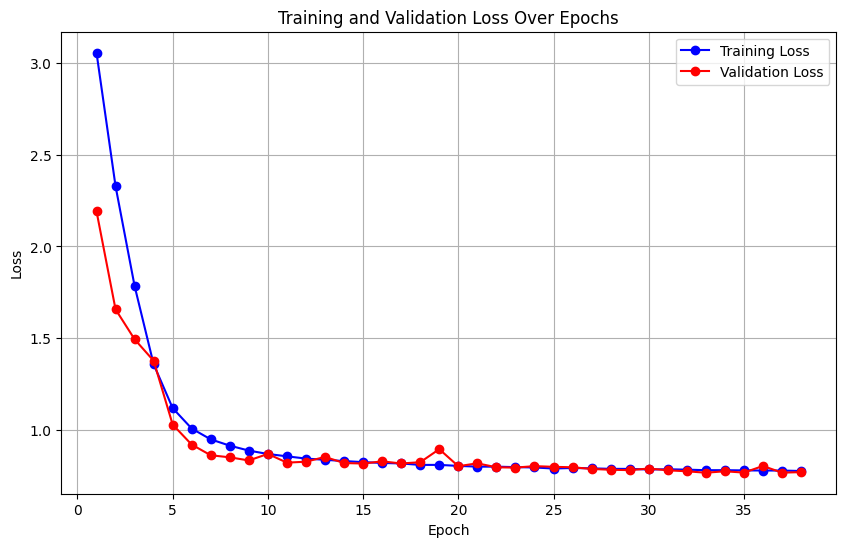

In [46]:
import matplotlib.pyplot as plt

def plot_learning_curve(train_losses, validation_losses):
    epochs = range(1, len(train_losses) + 1)
    
    plt.figure(figsize=(10, 6))
    plt.plot(epochs, train_losses, 'bo-', label='Training Loss')
    plt.plot(epochs, validation_losses, 'ro-', label='Validation Loss')
    
    plt.title('Training and Validation Loss Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

# After your training loop finishes and you have train_losses and validation_losses:
plot_learning_curve(train_losses, validation_losses)

NameError: name 'stopping_epoch' is not defined

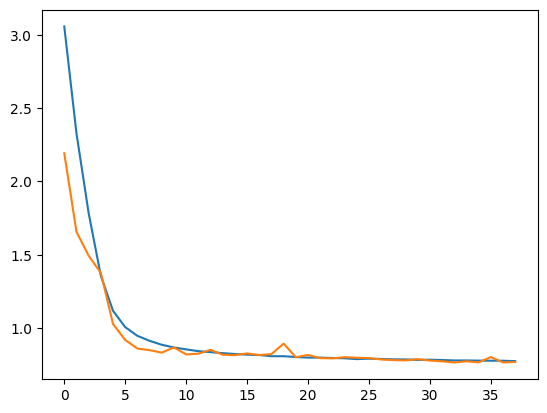

In [29]:
plt.plot(train_losses , label = 'train_loss')
plt.plot(validation_losses , label = 'validation_loss')
plt.xticks(range(1,stopping_epoch + 1))
plt.xlabel('No of Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

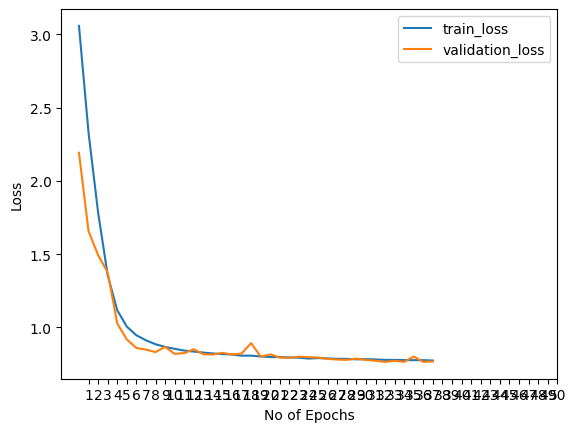

In [28]:
plt.plot(train_losses , label = 'train_loss')
plt.plot(validation_losses , label = 'validation_loss')
plt.xticks(range(1,number_of_epoch + 1))
plt.xlabel('No of Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

### Accuracy

In [30]:
from tabulate import tabulate  # pip install tabulate

def accuracy(loader, model, device):
    # Set model to evaluation mode
    model.eval()
    
    # Initialize counters
    n_correct = 0
    n_total = 0
    num_classes = len(loader.dataset.classes)
    correct_per_class = np.zeros(num_classes)
    total_per_class = np.zeros(num_classes)
    
    # Disable gradient computation
    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            _, predictions = torch.max(outputs, 1)
            
            # Update overall counters
            n_correct += (predictions == targets).sum().item()
            n_total += targets.size(0)
            
            # Update per-class counters
            for i in range(num_classes):
                correct_per_class[i] += ((predictions == i) & (targets == i)).sum().item()
                total_per_class[i] += (targets == i).sum().item()
    
    # Calculate overall accuracy
    overall_accuracy = n_correct / n_total
    
    # Calculate per-class accuracy
    per_class_accuracy = correct_per_class / total_per_class
    per_class_accuracy = np.nan_to_num(per_class_accuracy)  # Handle division by zero
    
    # Create table data using tabulate
    table_data = []
    for i, class_name in enumerate(loader.dataset.classes):
        table_data.append([class_name, f"{per_class_accuracy[i] * 100:.2f}"])
    
    print("\nPer-Class Accuracy:")
    print(tabulate(table_data, headers=["Category", "Accuracy (%)"], tablefmt="github"))
    
    return overall_accuracy, per_class_accuracy


In [31]:
train_overall_acc, per_class_acc = accuracy(train_loader, model, device)
print(f"Overall Accuracy: {train_overall_acc:.4f}\n")


Per-Class Accuracy:
| Category                                      |   Accuracy (%) |
|-----------------------------------------------|----------------|
| Apple___Apple_scab                            |         100    |
| Apple___Black_rot                             |         100    |
| Apple___Cedar_apple_rust                      |         100    |
| Apple___healthy                               |         100    |
| Background_without_leaves                     |          99.88 |
| Blueberry___healthy                           |         100    |
| Cherry___Powdery_mildew                       |         100    |
| Cherry___healthy                              |         100    |
| Corn___Cercospora_leaf_spot Gray_leaf_spot    |         100    |
| Corn___Common_rust                            |         100    |
| Corn___Northern_Leaf_Blight                   |         100    |
| Corn___healthy                                |         100    |
| Grape___Black_rot                      

In [32]:
val_overall_acc, per_class_acc = accuracy(validation_loader, model, device)
print(f"Overall Accuracy: {val_overall_acc:.4f}\n")
# for idx, class_acc in enumerate(per_class_acc):
#     print(f"Accuracy of {validation_loader.dataset.classes[idx]}: {class_acc:.4f}")


Per-Class Accuracy:
| Category                                      |   Accuracy (%) |
|-----------------------------------------------|----------------|
| Apple___Apple_scab                            |          100   |
| Apple___Black_rot                             |           99.5 |
| Apple___Cedar_apple_rust                      |          100   |
| Apple___healthy                               |           98   |
| Background_without_leaves                     |           99.5 |
| Blueberry___healthy                           |           99   |
| Cherry___Powdery_mildew                       |          100   |
| Cherry___healthy                              |           99   |
| Corn___Cercospora_leaf_spot Gray_leaf_spot    |           98   |
| Corn___Common_rust                            |          100   |
| Corn___Northern_Leaf_Blight                   |           96   |
| Corn___healthy                                |          100   |
| Grape___Black_rot                      

In [33]:
overall_acc, per_class_acc = accuracy(test_loader, model, device)
# print(f"Overall Accuracy: {overall_acc:.4f}\n")


Per-Class Accuracy:
| Category                                      |   Accuracy (%) |
|-----------------------------------------------|----------------|
| Apple___Apple_scab                            |           99.5 |
| Apple___Black_rot                             |           99.5 |
| Apple___Cedar_apple_rust                      |          100   |
| Apple___healthy                               |           97.5 |
| Background_without_leaves                     |           97.5 |
| Blueberry___healthy                           |           99.5 |
| Cherry___Powdery_mildew                       |          100   |
| Cherry___healthy                              |           99   |
| Corn___Cercospora_leaf_spot Gray_leaf_spot    |           97   |
| Corn___Common_rust                            |          100   |
| Corn___Northern_Leaf_Blight                   |           94   |
| Corn___healthy                                |          100   |
| Grape___Black_rot                      

In [34]:
print(
    f"Train Accuracy : {train_overall_acc} \nTest Accuracy : {overall_acc}\nValidation Accuracy : {val_overall_acc}"
)

Train Accuracy : 0.999951923076923 
Test Accuracy : 0.987948717948718
Validation Accuracy : 0.9893589743589744


### Precision, Recall and F1-score

In [35]:
import pandas as pd
from sklearn.metrics import classification_report

def evaluate_metrics(loader):
    y_true = []
    y_pred = []

    # Ensure model is in eval mode and disable gradients
    model.eval()
    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            _, predictions = torch.max(outputs, 1)
            
            y_true.extend(targets.cpu().numpy())
            y_pred.extend(predictions.cpu().numpy())
    
    # Get the report as a dictionary
    report_dict = classification_report(y_true, y_pred, target_names=dataset.classes, output_dict=True)
    
    # Convert dictionary to a Pandas DataFrame and transpose it so that each row is a class.
    report_df = pd.DataFrame(report_dict).transpose()
    return report_df

# Calculate metrics for each set
train_report = evaluate_metrics(train_loader)
validation_report = evaluate_metrics(validation_loader)
test_report = evaluate_metrics(test_loader)

In [36]:
# Write the reports to an Excel file with multiple sheets
excel_filename = "metrics_increased_epoch_to_50(5).xlsx"
with pd.ExcelWriter(excel_filename) as writer:
    train_report.to_excel(writer, sheet_name="train")
    validation_report.to_excel(writer, sheet_name="validation")
    test_report.to_excel(writer, sheet_name="test")

print(f"Metrics saved to {excel_filename}")

Metrics saved to metrics_increased_epoch_to_50(5).xlsx


In [ ]:
#### Changed the name to metrics_increased_epoch_to_50.xlsx

### Confusion Matrix

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def evaluate_confusion_matrix(loader):
    y_true = []
    y_pred = []
    
    # Ensure the model is in evaluation mode
    model.eval()
    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            
            outputs = model(inputs)
            _, predictions = torch.max(outputs, 1)
            
            y_true.extend(targets.cpu().numpy())
            y_pred.extend(predictions.cpu().numpy())
    
    # Compute the confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    # Convert to a DataFrame for better labeling
    cm_df = pd.DataFrame(cm, index=dataset.classes, columns=dataset.classes)
    return cm_df

def plot_confusion_matrix(cm_df, title="Confusion Matrix"):
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", cbar=True, annot_kws={"size": 8})
    plt.title(title, fontsize=18)
    plt.ylabel("Actual", fontsize=14)
    plt.xlabel("Predicted", fontsize=14)
    plt.show()

In [38]:
# Evaluate confusion matrices for train, validation, and test sets
cm_train = evaluate_confusion_matrix(train_loader)
cm_val = evaluate_confusion_matrix(validation_loader)
cm_test = evaluate_confusion_matrix(test_loader)

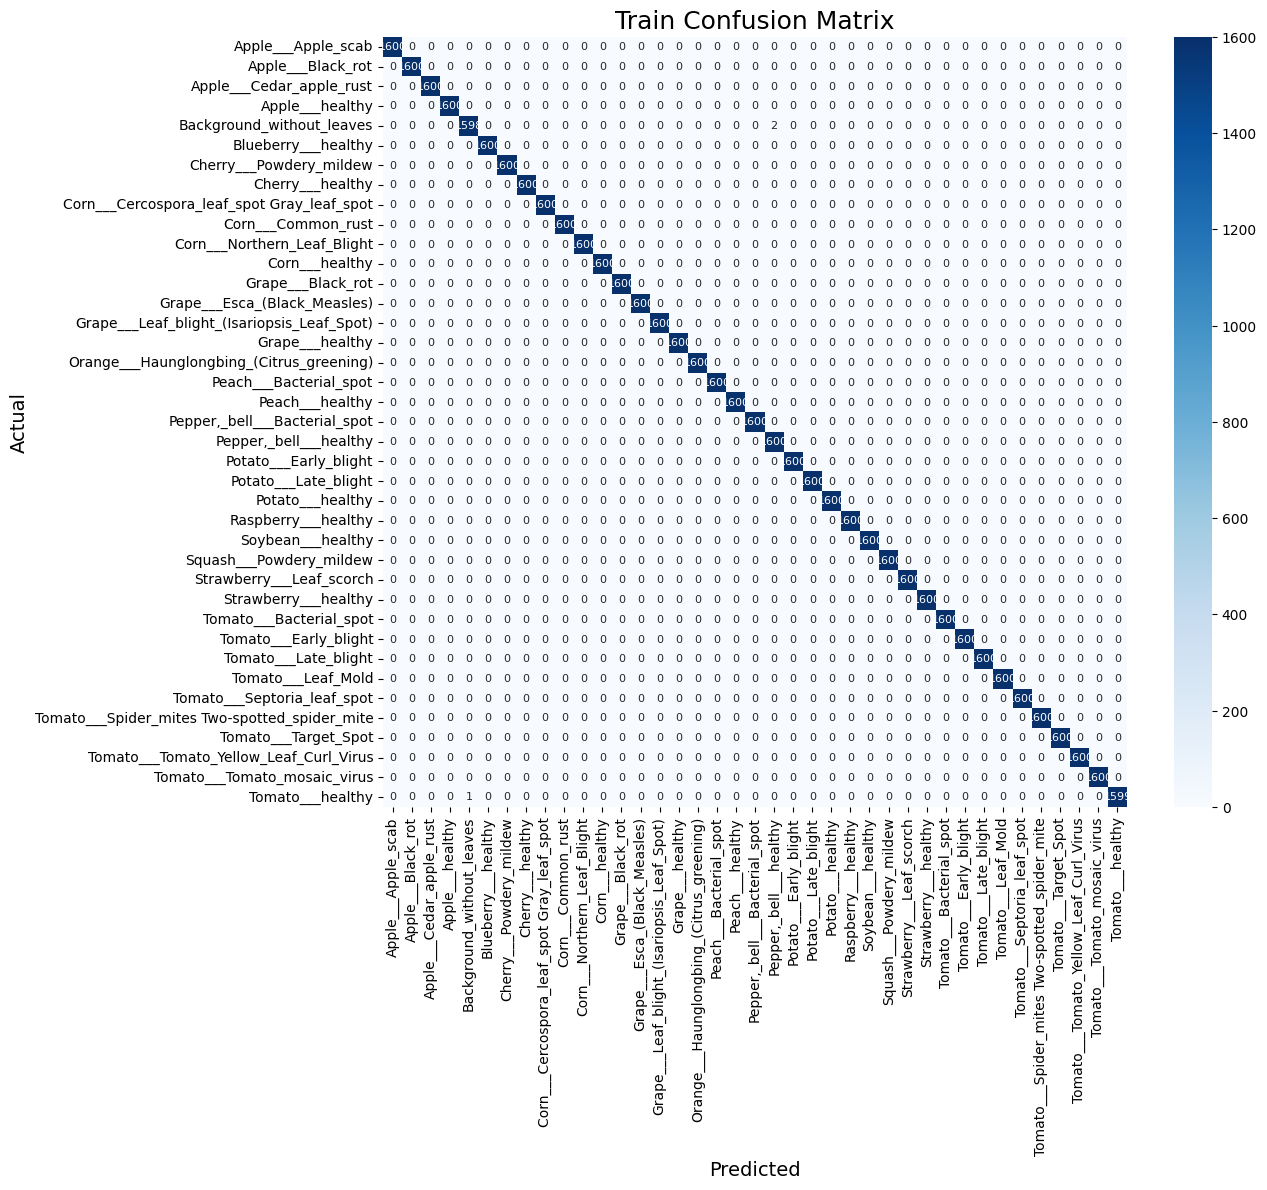

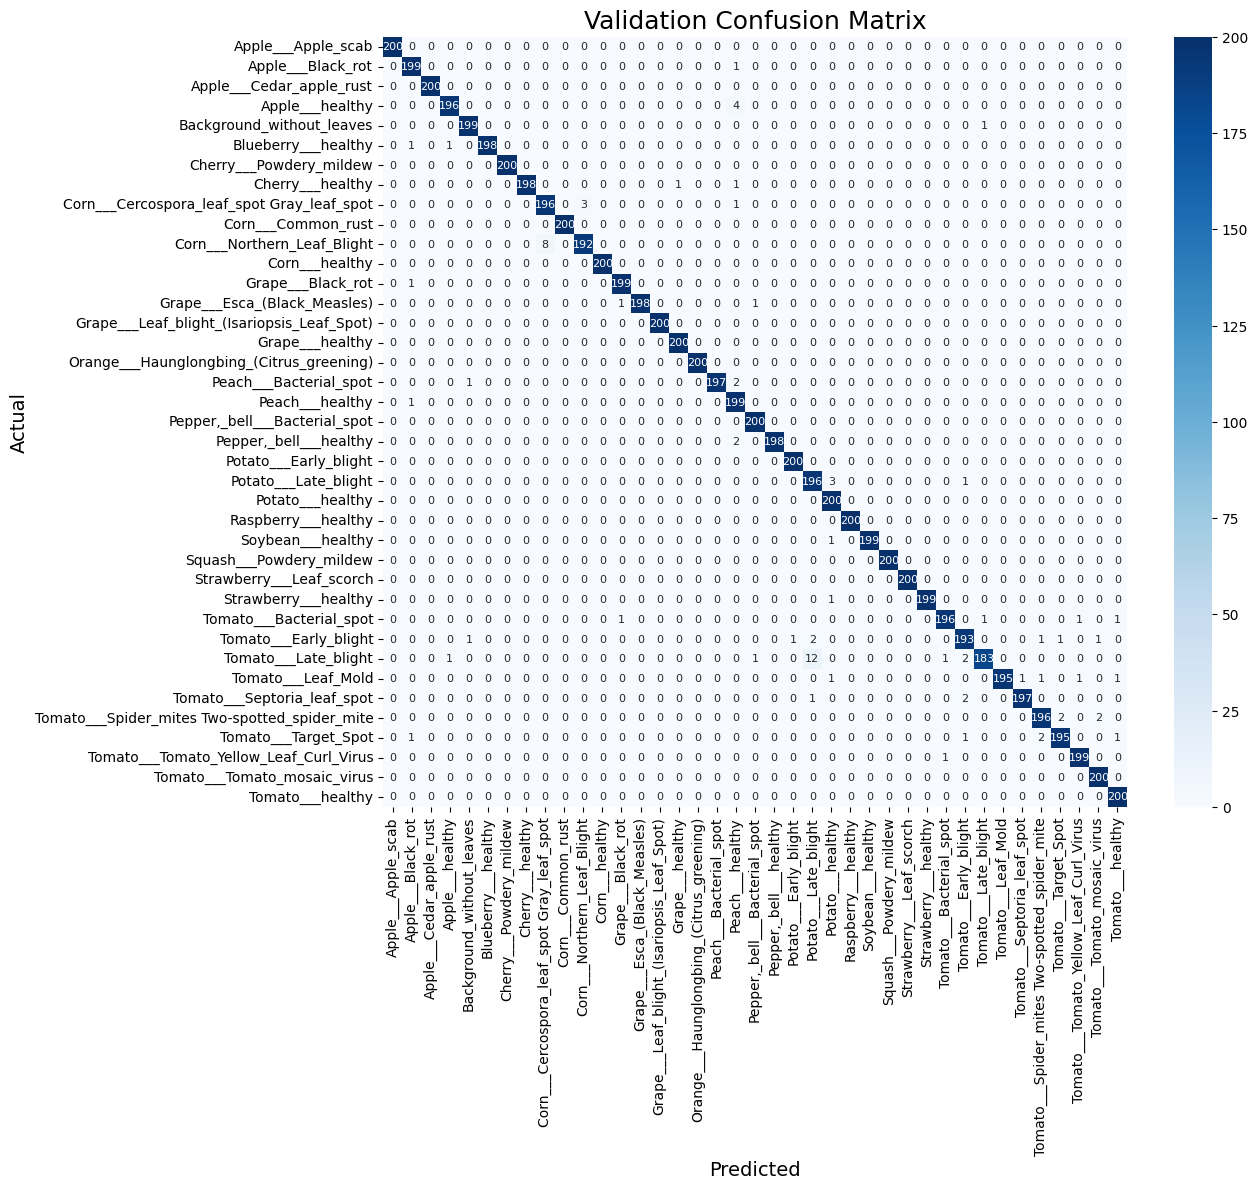

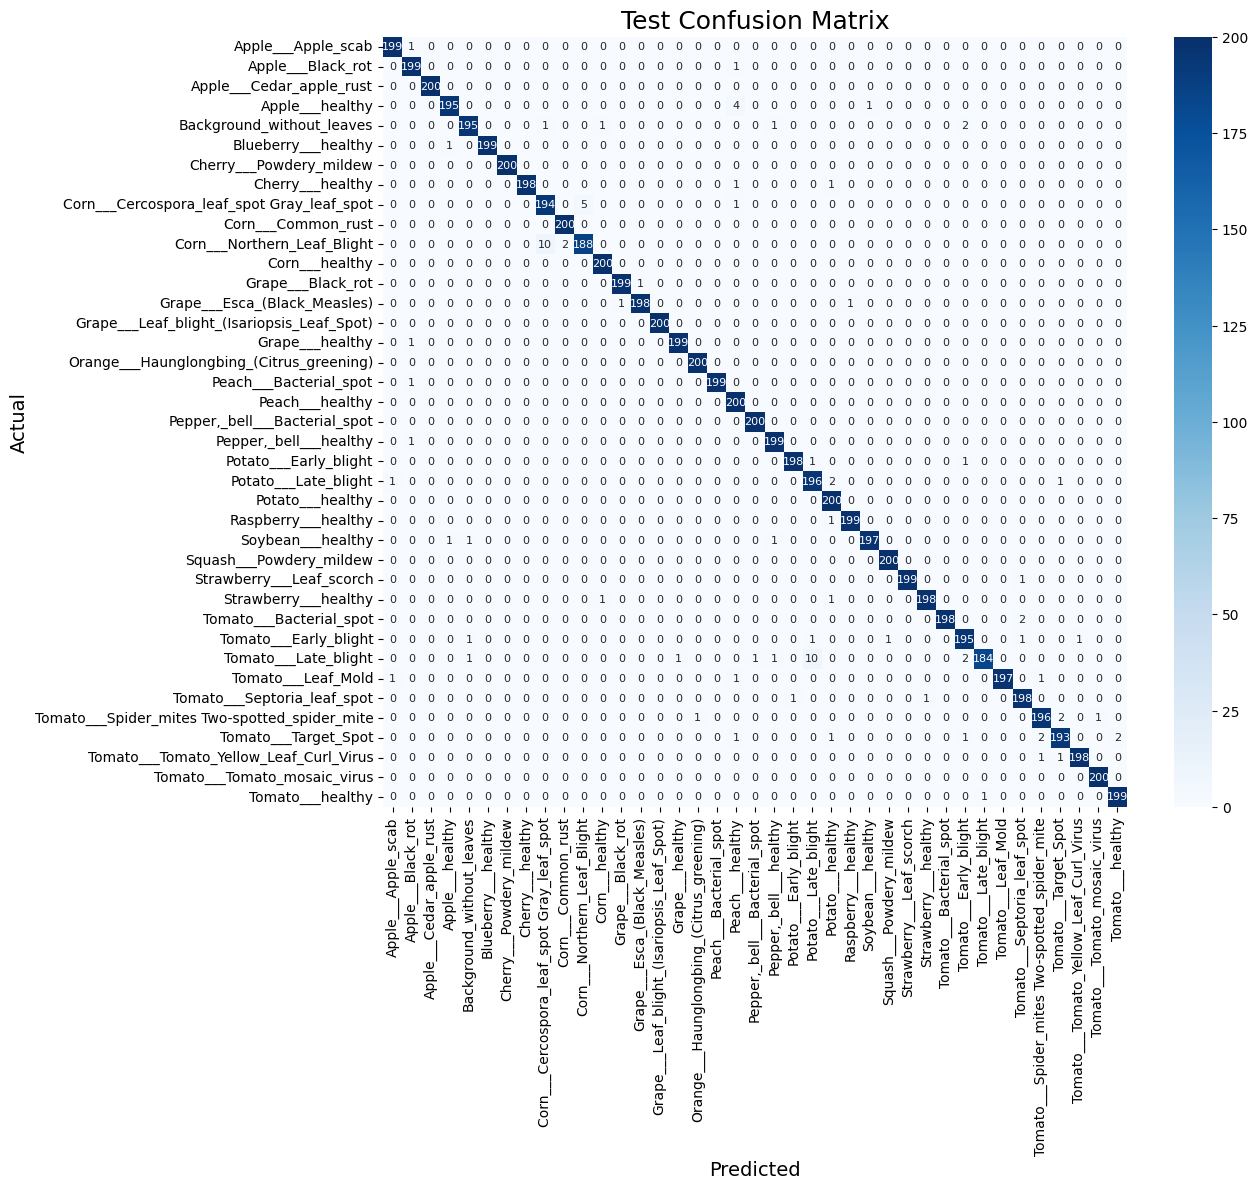

In [39]:
# Plot the confusion matrices
plot_confusion_matrix(cm_train, title="Train Confusion Matrix")
plot_confusion_matrix(cm_val, title="Validation Confusion Matrix")
plot_confusion_matrix(cm_test, title="Test Confusion Matrix")